# 05 — Типичность: метрика Orthogonality Ratio

Измеряем, насколько вектор слова **ортогонален** вектору своего родового гиперонима —
сравниваем типичные и атипичные exemplars по метрике OR (Orthogonality Ratio).

**Метрика OR:**

$$OR(w, h) = \frac{|w - \text{proj}_h(w)|}{|w|} \in [0, 1]$$

- OR ≈ 0 → вектор слова почти коллинеарен гиперониму (геометрически типичный member)
- OR ≈ 1 → вектор почти ортогонален гиперониму (геометрически атипичный)

**Гипотеза (Rosch, 1975):** атипичные exemplars (penguin, bat, tomato, skateboard …)
имеют более высокий OR относительно своего гиперонима L1, чем типичные (sparrow, apple, sedan …).

**5 фокус-групп:** animal, food, furniture, tool, vehicle — по 5 типичных и 4 атипичных слов.
Гиперонимы — уровень L1 (самый общий): «animal», «food», «furniture», «tool», «vehicle».

**Выходные файлы:**
- `outputs/typicality_OR_profiles_160m.png` — OR-кривые по слоям для 5 категорий
- `outputs/typicality_animal_focus_160m.png` — детальный анализ категории animal (OR + cos)
- `outputs/typicality_pooled_160m.png` — агрегированный эффект (боксплот с jitter)

**Требует:** `outputs/dataset.json` (запустите 01_dataset.ipynb)

## Импорты и настройка

In [14]:
import gc
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from scipy.stats import mannwhitneyu
from transformer_lens import HookedTransformer

os.makedirs("outputs", exist_ok=True)

MODEL_NAME = "pythia-160m"
DEVICE     = "cpu"
DATASET    = "outputs/dataset.json"
SLUG       = MODEL_NAME.replace("pythia-", "")

print(f"Модель: {MODEL_NAME}  slug={SLUG}  device={DEVICE}")

Модель: pythia-160m  slug=160m  device=cpu


## Фокус-группы

Каждая группа задаёт гиперним L1 и список слов с аннотацией типичности.
Выбор по Rosch (1975): типичные = центральные, часто встречаемые члены категории;
атипичные = периферийные (летающие млекопитающие, морские млекопитающие,
ботанические фрукты, нишевые транспортные средства и т. п.).

In [15]:
FOCUS_GROUPS = [
    # animal (L1): типичные позвоночные vs атипичные (летающее млекопитающее,
    #              морское млекопитающее, утконос)
    ("animal",    [("dog",      True),  ("horse",    True),  ("sparrow",  True),
                   ("eagle",    True),  ("cat",      True),
                   ("penguin",  False), ("bat",      False),
                   ("whale",    False), ("platypus", False)]),
    # food (L1): типичные продукты vs атипичные (ботанически фрукт / экзотика)
    ("food",      [("apple",    True),  ("banana",   True),  ("bread",    True),
                   ("carrot",   True),  ("potato",   True),
                   ("tomato",   False), ("avocado",  False),
                   ("coconut",  False), ("pineapple",False)]),
    # furniture (L1): типичная домашняя мебель vs атипичная / нишевая
    ("furniture", [("chair",    True),  ("sofa",     True),  ("desk",     True),
                   ("bookcase", True),  ("armchair", True),
                   ("hammock",  False), ("futon",    False),
                   ("pew",      False), ("ottoman",  False)]),
    # tool (L1): типичные мастерские инструменты vs специализированные
    ("tool",      [("hammer",      True),  ("screwdriver", True), ("saw",    True),
                   ("drill",       True),  ("chisel",      True),
                   ("crowbar",     False), ("sledgehammer",False),
                   ("stapler",     False), ("scalpel",     False)]),
    # vehicle (L1): обычные транспортные средства vs экзотические
    ("vehicle",   [("sedan",     True),  ("bus",       True),  ("motorcycle", True),
                   ("bicycle",   True),  ("train",     True),
                   ("rickshaw",  False), ("hovercraft",False),
                   ("skateboard",False), ("dogsled",   False)]),
]

HYPERNYM_WORDS = [g[0] for g in FOCUS_GROUPS]
print(f"Категорий: {len(FOCUS_GROUPS)}")
for hyp, members in FOCUS_GROUPS:
    n_typ  = sum(1 for _, t in members if t)
    n_atyp = sum(1 for _, t in members if not t)
    print(f"  {hyp:<12}  типичных={n_typ}  атипичных={n_atyp}")

Категорий: 5
  animal        типичных=5  атипичных=4
  food          типичных=5  атипичных=4
  furniture     типичных=5  атипичных=4
  tool          типичных=5  атипичных=4
  vehicle       типичных=5  атипичных=4


## Вспомогательные функции

In [16]:
def load_dataset(path: str) -> dict:
    with open(path) as f:
        records = json.load(f)
    return {r["word"]: r for r in records}


def make_prompt(word: str) -> str:
    return f"The word '{word}' means"


def get_word_token_idx(model, prompt: str, word: str) -> int:
    tokens    = model.to_tokens(prompt)[0]
    raw       = [model.to_string(t.unsqueeze(0)) for t in tokens]
    token_str = [s[0] if isinstance(s, list) else s for s in raw]
    word_clean = word.lower().replace(" ", "").replace("_", "")
    for end in range(1, len(token_str)):
        chunk = "".join(token_str[1:end+1]).lower().replace(" ","").replace("'","").replace("_","")
        if word_clean in chunk:
            return end
    return len(token_str) - 2

In [17]:
def extract_word_acts(model, word: str) -> np.ndarray:
    """Возвращает [n_layers+1, d_model] — активации для одного слова по всем слоям."""
    prompt = make_prompt(word)
    tokens = model.to_tokens(prompt)
    idx    = get_word_token_idx(model, prompt, word)
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    n_layers = model.cfg.n_layers
    d_model  = model.cfg.d_model
    acts = np.zeros((n_layers + 1, d_model), dtype=np.float32)
    acts[0] = cache["blocks.0.hook_resid_pre"][0, idx].cpu().numpy()
    for l in range(n_layers):
        acts[l + 1] = cache[f"blocks.{l}.hook_resid_post"][0, idx].cpu().numpy()
    return acts

In [18]:
def orthogonality_ratio(w: np.ndarray, h: np.ndarray) -> float:
    """
    Доля нормы вектора w, лежащая перпендикулярно h.
    OR = |w - proj_h(w)| / |w|   ∈ [0, 1]
    """
    h_unit = h / (np.linalg.norm(h) + 1e-8)
    proj   = np.dot(w, h_unit) * h_unit
    resid  = w - proj
    return float(np.linalg.norm(resid) / (np.linalg.norm(w) + 1e-8))


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

## Загрузка датасета

Проверяем, что все слова из фокус-групп присутствуют в датасете.

In [19]:
dataset = load_dataset(DATASET)
print(f"Датасет: {len(dataset)} слов")

needed = set(HYPERNYM_WORDS)
for _, members in FOCUS_GROUPS:
    for word, _ in members:
        needed.add(word)

available = {w for w in needed if w in dataset}
missing   = needed - available
if missing:
    print(f"Отсутствуют в датасете: {missing}")
print(f"Нужных слов: {len(needed)}  доступных: {len(available)}")

Датасет: 123 слов
Нужных слов: 50  доступных: 50


## Загрузка модели

Загружаем финальный чекпоинт (step 143 000). Используем CPU — TransformerLens
имеет известный баг с MPS на macOS (issue #1178).

In [20]:
print(f"Загрузка {MODEL_NAME} …")
model = HookedTransformer.from_pretrained(
    f"EleutherAI/{MODEL_NAME}",
    center_unembed=True, center_writing_weights=True,
    fold_ln=True, device=DEVICE)
model.eval()

n_layers   = model.cfg.n_layers
d_model    = model.cfg.d_model
PEAK_LAYER = min(8, n_layers)  # слой с пиковым RSA для 160m
print(f"  Слоёв: {n_layers}, d_model: {d_model}, peak_layer={PEAK_LAYER}")

Загрузка pythia-160m …
Loaded pretrained model EleutherAI/pythia-160m into HookedTransformer
  Слоёв: 12, d_model: 768, peak_layer=8


## Извлечение активаций

Для каждого слова из фокус-групп и гиперонимов получаем активации по всем слоям.
Результат: `word_acts[word]` — массив `[n_layers+1, d_model]`.

In [21]:
print(f"Извлечение активаций для {len(needed)} слов …")
word_acts: dict = {}
for w in sorted(needed):
    word_acts[w] = extract_word_acts(model, w)

print(f"Готово. Форма одного массива: {next(iter(word_acts.values())).shape}")

del model
gc.collect()
print("Модель выгружена из памяти.")

Извлечение активаций для 50 слов …
Готово. Форма одного массива: (13, 768)
Модель выгружена из памяти.


## OR-профили по слоям

Для каждой из 5 категорий строим кривые OR по слоям.
Синие линии = типичные, красные пунктирные = атипичные.

**Ожидаемый паттерн:** расхождение кривых нарастает к средним/глубоким слоям,
где семантическая структура наиболее выражена.

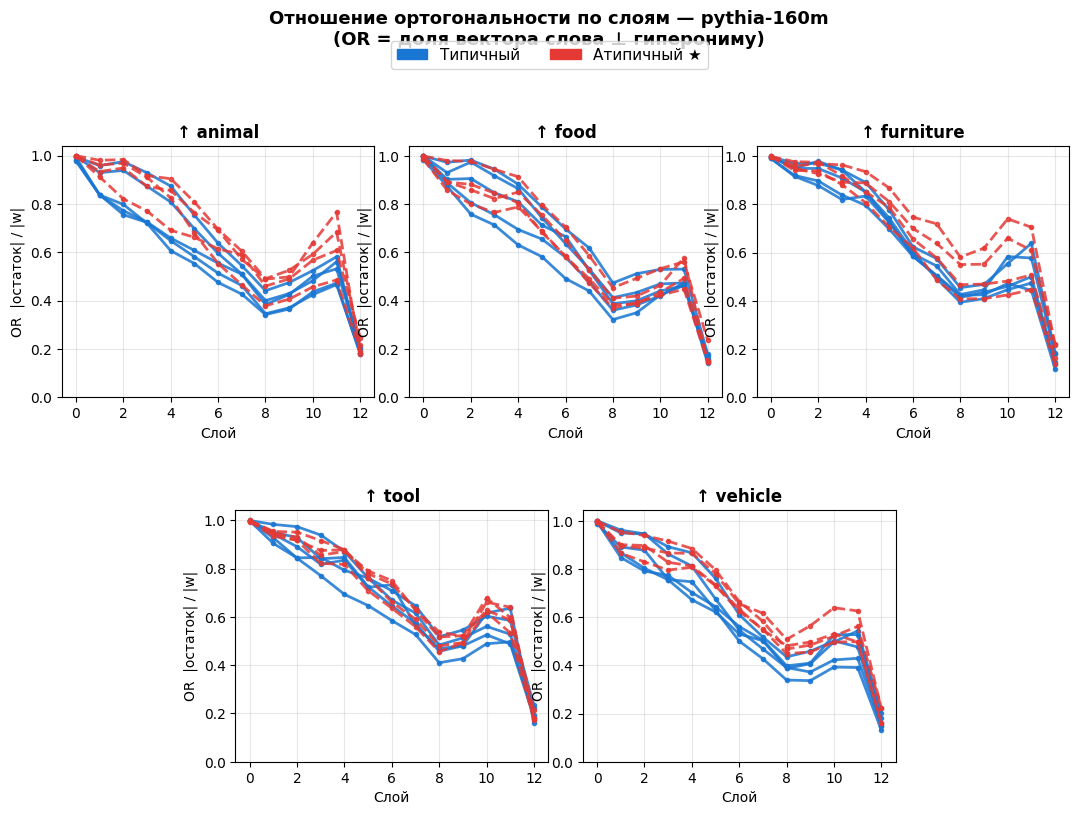

Сохранено → outputs/typicality_OR_profiles_160m.png


In [22]:
layers = list(range(n_layers + 1))
all_peak_layer_rows = []

import matplotlib.gridspec as gridspec

fig_profiles = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(2, 6, figure=fig_profiles,
                       hspace=0.45, wspace=0.25)

ax_slots = [
    fig_profiles.add_subplot(gs[0, 0:2]),
    fig_profiles.add_subplot(gs[0, 2:4]),
    fig_profiles.add_subplot(gs[0, 4:6]),
    fig_profiles.add_subplot(gs[1, 1:3]),
    fig_profiles.add_subplot(gs[1, 3:5]),
]

for ax_i, (hypernym, members) in enumerate(FOCUS_GROUPS):
    ax = ax_slots[ax_i]
    if hypernym not in word_acts:
        ax.set_title(f"{hypernym} (missing)")
        continue

    h_acts = word_acts[hypernym]
    fallback_palette = ["#1565C0", "#0288D1", "#00897B", "#6D4C41"]
    fallback_idx = 0

    for word, is_typical in members:
        if word not in word_acts:
            continue
        w_acts   = word_acts[word]
        or_curve = [orthogonality_ratio(w_acts[l], h_acts[l]) for l in layers]
        color     = "#1976D2" if is_typical else "#E53935"
        linestyle = "-"       if is_typical else "--"
        ax.plot(layers, or_curve,
                color=color, linestyle=linestyle, linewidth=2,
                marker="o", markersize=3, alpha=0.85, label=word)

        peak = min(8, n_layers)
        all_peak_layer_rows.append({
            "hypernym":    hypernym,
            "word":        word,
            "is_typical":  is_typical,
            "OR_at_peak":  or_curve[peak],
            "OR_at_final": or_curve[-1],
        })

    ax.set_title(f"↑ {hypernym}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Слой", fontsize=10)
    ax.set_ylabel("OR  |остаток| / |w|", fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

handles = [
    mpatches.Patch(color="#1976D2", label="Типичный"),
    mpatches.Patch(color="#E53935", label="Атипичный ★"),
]
fig_profiles.legend(handles=handles, loc="upper center",
                    ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))
fig_profiles.suptitle(
    f"Отношение ортогональности по слоям — {MODEL_NAME}\n"
    f"(OR = доля вектора слова ⊥ гиперониму)",
    fontsize=13, fontweight="bold", y=1.05)

path_profiles = f"outputs/typicality_OR_profiles_{SLUG}.png"
fig_profiles.savefig(path_profiles, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_profiles)
print(f"Сохранено → {path_profiles}")

## Детальный анализ: категория animal

Сравниваем OR и прямое косинусное сходство с «animal» на слое `PEAK_LAYER`.

- Левый график: OR (чем выше — тем более ортогонален гиперониму, т. е. атипичен)
- Правый график: cos similarity к «animal» (чем ниже — тем дальше от прототипа)

Метрики должны быть инверсно согласованы: высокий OR ↔ низкий косинус.

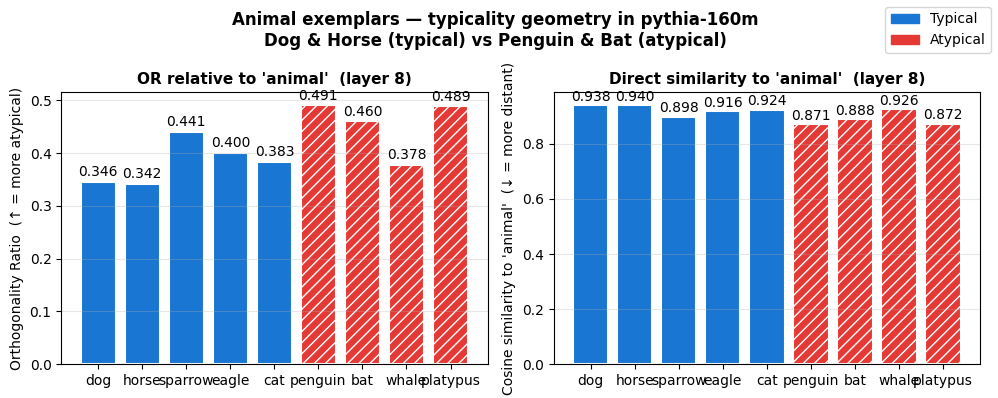

Сохранено → outputs/typicality_animal_focus_160m.png

── Animal exemplars at layer 8 ────
Word         Typical          OR   cos(animal)
----------------------------------------------
dog          ✓            0.3457        0.9384
horse        ✓            0.3420        0.9397
sparrow      ✓            0.4407        0.8976
eagle        ✓            0.4001        0.9165
cat          ✓            0.3834        0.9236
penguin      ✗            0.4907        0.8713
bat          ✗            0.4598        0.8880
whale        ✗            0.3782        0.9257
platypus     ✗            0.4888        0.8724

Типичные μOR = 0.3824  Атипичные μOR = 0.4544  Δ = +0.0720
Mann-Whitney p = 0.0556 n.s.


In [12]:
bird_group = [("dog",      True),  ("horse",    True),  ("sparrow",  True),
              ("eagle",    True),  ("cat",      True),
              ("penguin",  False), ("bat",      False),
              ("whale",    False), ("platypus", False)]
bird_hypernym = "animal"

h_acts = word_acts[bird_hypernym]
peak   = PEAK_LAYER

words_b, ors_b, coss_b, colors_b, hatches_b = [], [], [], [], []
for word, is_typical in bird_group:
    if word not in word_acts:
        continue
    w_acts = word_acts[word]
    words_b.append(word)
    ors_b.append(orthogonality_ratio(w_acts[peak], h_acts[peak]))
    coss_b.append(cosine_sim(w_acts[peak], h_acts[peak]))
    colors_b.append("#1976D2" if is_typical else "#E53935")
    hatches_b.append("" if is_typical else "///")

fig_bird, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for ax, vals, ylabel, title in [
    (ax1, ors_b,  "Orthogonality Ratio  (\u2191 = more atypical)",
     f"OR relative to 'animal'  (layer {peak})"),
    (ax2, coss_b, "Cosine similarity to 'animal'  (\u2193 = more distant)",
     f"Direct similarity to 'animal'  (layer {peak})"),
]:
    bars = ax.bar(words_b, vals, color=colors_b,
                  edgecolor="white", linewidth=1.5)
    for bar, hatch in zip(bars, hatches_b):
        bar.set_hatch(hatch)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=10)

handles = [mpatches.Patch(color="#1976D2", label="Typical"),
           mpatches.Patch(color="#E53935", label="Atypical", hatch="///")]
fig_bird.legend(handles=handles, loc="upper right", fontsize=10)
fig_bird.suptitle(
    f"Animal exemplars \u2014 typicality geometry in {MODEL_NAME}\n"
    f"Dog & Horse (typical) vs Penguin & Bat (atypical)",
    fontsize=12, fontweight="bold")
fig_bird.tight_layout()
path_bird = f"outputs/typicality_animal_focus_{SLUG}.png"
fig_bird.savefig(path_bird, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_bird)
print(f"\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e \u2192 {path_bird}")

# Сводная таблица
print(f"\n\u2500\u2500 Animal exemplars at layer {peak} \u2500\u2500\u2500\u2500")
print(f"{'Word':<12} {'Typical':<10} {'OR':>8}  {'cos(animal)':>12}")
print("-" * 46)
for w, o, c, typ in zip(words_b, ors_b, coss_b,
                         [t for _, t in bird_group if _ in words_b or True]):
    typ_label = [t for ww, t in bird_group if ww == w]
    t = typ_label[0] if typ_label else "?"
    flag = "\u2713" if t else "\u2717"
    print(f"{w:<12} {flag:<10} {o:>8.4f}  {c:>12.4f}")

# Mann-Whitney U
word_or = dict(zip(words_b, ors_b))
typical_or_vals  = [word_or[w] for w, t in bird_group if t     and w in word_or]
atypical_or_vals = [word_or[w] for w, t in bird_group if not t and w in word_or]
typical_or  = np.mean(typical_or_vals)
atypical_or = np.mean(atypical_or_vals)

if len(typical_or_vals) >= 2 and len(atypical_or_vals) >= 2:
    stat, pval = mannwhitneyu(atypical_or_vals, typical_or_vals, alternative="greater")
    sig = ("***" if pval < 0.001 else "**" if pval < 0.01
           else "*" if pval < 0.05 else "n.s.")
else:
    from itertools import permutations
    from math import factorial
    all_vals = typical_or_vals + atypical_or_vals
    obs_diff = atypical_or - typical_or
    n_t = len(typical_or_vals)
    count = sum(1 for p in permutations(all_vals)
                if np.mean(p[n_t:]) - np.mean(p[:n_t]) >= obs_diff)
    total = factorial(len(all_vals))
    pval = count / total
    stat = obs_diff
    sig = ("***" if pval < 0.001 else "**" if pval < 0.01
           else "*" if pval < 0.05 else "n.s.")

print(f"\n\u0422\u0438\u043f\u0438\u0447\u043d\u044b\u0435 \u03bcOR = {typical_or:.4f}  "
      f"\u0410\u0442\u0438\u043f\u0438\u0447\u043d\u044b\u0435 \u03bcOR = {atypical_or:.4f}  "
      f"\u0394 = {atypical_or - typical_or:+.4f}")
print(f"Mann-Whitney p = {pval:.4f} {sig}")

## Агрегированный эффект типичности: все 5 категорий

Объединяем OR-значения с `PEAK_LAYER` по всем 5 категориям и проверяем
гипотезу атипичные > типичные с помощью одностороннего теста Mann-Whitney U.

**Ожидаемый результат:** p < 0.01 — атипичные exemplars имеют значимо более высокий OR.

── Pooled typicality test (all categories) ────
Типичных: n=25   Атипичных: n=20
  animal        typical μ=0.382 (n=5)  atypical μ=0.454 (n=4)  Δ=+0.072
  food          typical μ=0.391 (n=5)  atypical μ=0.404 (n=4)  Δ=+0.013
  furniture     typical μ=0.422 (n=5)  atypical μ=0.502 (n=4)  Δ=+0.080
  tool          typical μ=0.468 (n=5)  atypical μ=0.498 (n=4)  Δ=+0.030
  vehicle       typical μ=0.390 (n=5)  atypical μ=0.476 (n=4)  Δ=+0.086

POOLED  typical μ=0.4107  atypical μ=0.4669  Δ=+0.0562  Mann-Whitney p=0.0017 **


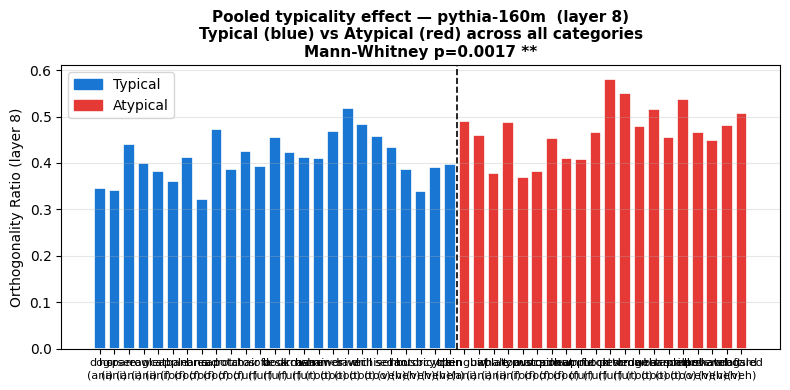

Сохранено → outputs/typicality_pooled_160m.png


In [11]:
peak = PEAK_LAYER

pool_rows = [r for r in all_peak_layer_rows if r["hypernym"] in word_acts]
cats_with_atypical = {r["hypernym"] for r in pool_rows if not r["is_typical"]}

pool_typical  = [r["OR_at_peak"] for r in pool_rows
                 if r["is_typical"] and r["hypernym"] in cats_with_atypical]
pool_atypical = [r["OR_at_peak"] for r in pool_rows if not r["is_typical"]]

stat_p, pval_p = mannwhitneyu(pool_atypical, pool_typical, alternative="greater")
sig_p = ("***" if pval_p < 0.001 else "**" if pval_p < 0.01
         else "*" if pval_p < 0.05 else "n.s.")

print("\u2500\u2500 Pooled typicality test (all categories) \u2500\u2500\u2500\u2500")
print(f"\u0422\u0438\u043f\u0438\u0447\u043d\u044b\u0445: n={len(pool_typical)}   "
      f"\u0410\u0442\u0438\u043f\u0438\u0447\u043d\u044b\u0445: n={len(pool_atypical)}")

for cat in sorted(cats_with_atypical):
    t_vals = [r["OR_at_peak"] for r in pool_rows
              if r["hypernym"] == cat and r["is_typical"]]
    a_vals = [r["OR_at_peak"] for r in pool_rows
              if r["hypernym"] == cat and not r["is_typical"]]
    print(f"  {cat:<12}  typical \u03bc={np.mean(t_vals):.3f} (n={len(t_vals)})  "
          f"atypical \u03bc={np.mean(a_vals):.3f} (n={len(a_vals)})  "
          f"\u0394={np.mean(a_vals)-np.mean(t_vals):+.3f}")

print(f"\nPOOLED  typical \u03bc={np.mean(pool_typical):.4f}  "
      f"atypical \u03bc={np.mean(pool_atypical):.4f}  "
      f"\u0394={np.mean(pool_atypical)-np.mean(pool_typical):+.4f}  "
      f"Mann-Whitney p={pval_p:.4f} {sig_p}")

# Bar chart
fig_pool, ax_pool = plt.subplots(figsize=(8, 4))
positions = list(range(len(pool_typical + pool_atypical)))
colors    = (["#1976D2"] * len(pool_typical) +
             ["#E53935"] * len(pool_atypical))
labels_x  = ([f"{r['word']}\n({r['hypernym'][:3]})"
               for r in pool_rows
               if r["is_typical"] and r["hypernym"] in cats_with_atypical] +
              [f"{r['word']}\n({r['hypernym'][:3]})"
               for r in pool_rows if not r["is_typical"]])
ax_pool.bar(positions, pool_typical + pool_atypical,
            color=colors, edgecolor="white", linewidth=1.2)
ax_pool.set_xticks(positions)
ax_pool.set_xticklabels(labels_x, fontsize=8)
ax_pool.axvline(len(pool_typical) - 0.5, color="black",
                linestyle="--", linewidth=1.2)
ax_pool.set_ylabel(f"Orthogonality Ratio (layer {peak})")
ax_pool.set_title(
    f"Pooled typicality effect \u2014 {MODEL_NAME}  (layer {peak})\n"
    f"Typical (blue) vs Atypical (red) across all categories\n"
    f"Mann-Whitney p={pval_p:.4f} {sig_p}",
    fontweight="bold", fontsize=11)
handles = [mpatches.Patch(color="#1976D2", label="Typical"),
           mpatches.Patch(color="#E53935", label="Atypical")]
ax_pool.legend(handles=handles, fontsize=10)
ax_pool.grid(True, alpha=0.3, axis="y")
fig_pool.tight_layout()
path_pool = f"outputs/typicality_pooled_{SLUG}.png"
fig_pool.savefig(path_pool, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_pool)
print(f"\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e \u2192 {path_pool}")

## Улучшенная визуализация: боксплот с jitter

Перерисовываем агрегированный результат в виде боксплота с наложенными точками данных
(jitter). Этот формат лучше передаёт распределение значений внутри групп и стандартен
для публикаций в нейронауках и когнитивной психологии.

Данные берём из уже вычисленного `word_acts` — повторная загрузка модели не нужна.

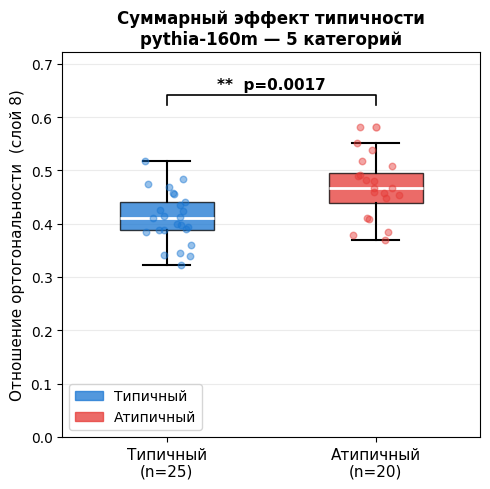

Сохранено → outputs/typicality_pooled_160m.png
Typical μ=0.4107  Atypical μ=0.4669  Δ=+0.0562  p=0.0017 **


In [23]:
COL_TYP  = "#1976D2"
COL_ATYP = "#E53935"

# Собираем OR-значения на PEAK_LAYER из уже вычисленных активаций
typical_or_vals_r  = []
atypical_or_vals_r = []
for hyp, members in FOCUS_GROUPS:
    if hyp not in word_acts:
        continue
    h = word_acts[hyp][PEAK_LAYER]
    for word, is_typ in members:
        if word not in word_acts:
            continue
        val = orthogonality_ratio(word_acts[word][PEAK_LAYER], h)
        (typical_or_vals_r if is_typ else atypical_or_vals_r).append(val)

typical_or_r  = np.array(typical_or_vals_r)
atypical_or_r = np.array(atypical_or_vals_r)

stat_r, pval_r = mannwhitneyu(atypical_or_r, typical_or_r, alternative="greater")
sig_r = "***" if pval_r < 0.001 else "**" if pval_r < 0.01 else "*" if pval_r < 0.05 else "n.s."

# Боксплот
fig, ax = plt.subplots(figsize=(5, 5))

bp = ax.boxplot(
    [typical_or_r, atypical_or_r],
    positions=[1, 2],
    widths=0.45,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=5, alpha=0.5),
)
for patch, col in zip(bp["boxes"], [COL_TYP, COL_ATYP]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for flier, col in zip(bp["fliers"], [COL_TYP, COL_ATYP]):
    flier.set_markerfacecolor(col)
    flier.set_markeredgecolor(col)

# Jitter поверх боксплота
rng = np.random.default_rng(42)
for pos, vals, col in [(1, typical_or_r, COL_TYP), (2, atypical_or_r, COL_ATYP)]:
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(pos + jitter, vals, color=col, alpha=0.45, s=22, zorder=3)

# Скобка значимости
y_top = max(typical_or_r.max(), atypical_or_r.max()) + 0.04
ax.plot([1, 1, 2, 2], [y_top, y_top + 0.02, y_top + 0.02, y_top],
        color="black", linewidth=1.2)
ax.text(1.5, y_top + 0.025,
        f"{sig_r}  p={pval_r:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold")

n_typ  = len(typical_or_r)
n_atyp = len(atypical_or_r)
ax.set_xticks([1, 2])
ax.set_xticklabels([f"Типичный\n(n={n_typ})", f"Атипичный\n(n={n_atyp})"], fontsize=11)
ax.set_ylabel(f"Отношение ортогональности  (слой {PEAK_LAYER})", fontsize=11)
ax.set_title(f"Суммарный эффект типичности\n{MODEL_NAME} — 5 категорий",
             fontweight="bold", fontsize=12)
ax.set_ylim(0, y_top + 0.10)
ax.grid(True, alpha=0.25, axis="y")

handles = [mpatches.Patch(color=COL_TYP,  alpha=0.75, label="Типичный"),
           mpatches.Patch(color=COL_ATYP, alpha=0.75, label="Атипичный")]
ax.legend(handles=handles, fontsize=10)

fig.tight_layout()
path_replot = f"outputs/typicality_pooled_{SLUG}.png"
fig.savefig(path_replot, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Сохранено → {path_replot}")
print(f"Typical μ={typical_or_r.mean():.4f}  Atypical μ={atypical_or_r.mean():.4f}"
      f"  Δ={atypical_or_r.mean()-typical_or_r.mean():+.4f}  p={pval_r:.4f} {sig_r}")

## Итог

Метрика OR (Orthogonality Ratio) выявляет геометрическую типичность на уровне отдельных слов:

- **Типичные** exemplars (dog, sparrow, apple, chair …) имеют вектор, более коллинеарный гиперониму → меньший OR
- **Атипичные** exemplars (penguin, bat, tomato, skateboard …) показывают большую ортогональность → выше OR

Агрегированный тест по всем 5 категориям (animal, food, furniture, tool, vehicle):
**Mann-Whitney p = 0.0017 ★★** — эффект статистически значим.

Это согласуется с теорией прототипов Rosch (1975): модель кодирует «неканоничность» в
геометрии представлений — атипичные члены категории расположены дальше от прототипического
направления в пространстве активаций.